In [1]:
#Dependencies

import sys
from pathlib import Path
import torch
import numpy as np
import pandas as pd
from time import time
from matplotlib import pyplot as plt

"""import os # Debugging for cpu-only context
os.environ["CUDA_VISIBLE_DEVICES"] = ""
torch.cuda.is_available = lambda : False # Force CPU-only context for testing and compatibility"""

sys.path.append("C:\\Users\\dashf\\Downloads\\alphaMELTSEnsemble-master\\BJT2025\\PTT_Test\\PetThermoTools-0.2.39\\PetThermoTools-0.2.39\\MELTS\\") # On BJT local machine
import petthermotools as ptt

# Handle both notebook and script contexts
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    # Running in Jupyter notebook context
    repo_root = Path.cwd().parent



# Add both src and src/nMELTS to path
src_root = repo_root / "src"
nmelts_root = src_root / "ngibbs"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
if str(nmelts_root) not in sys.path:
    sys.path.insert(0, str(nmelts_root))


#import builder.HeFESTo


# Import utilities and API
from ngibbs.utils.math_utils import grid_sample, grid_sample_explicit, mix_compositions, match_rows
from ngibbs import MELTS102EmulatorCPU
from ngibbs.config.constants import OXIDE_MOLAR_MASSES as oxide_molar_masses, ptt_oxide_indexer, ptt_to_short


ferric_to_ferrous =  (2*oxide_molar_masses['FeO'])/oxide_molar_masses['Fe2O3']

if torch.cuda.is_available():
    from ngibbs import MELTS102EmulatorGPU # Optional GPU emulator, only imported if CUDA is available

print("Imports successful!")
print(f"Repository root: {repo_root}")
print(f"nMELTS root: {nmelts_root}")


print("\nEmulators available:")
print(f"  - MELTS102EmulatorCPU")
if torch.cuda.is_available():
    print(f"  - MELTS102EmulatorGPU")


compositions = {
    'Fernandina MI': {
        'SiO2': 47.5,
        'TiO2': 2.29,
        'Al2O3': 16.4,
        'FeO': 8.25,
        'Fe2O3': 1.0, # Arbitrary Fe speciation, nGibbs supports buffering, but I don't yet have freshly trained models for that yet. 
         #'MnO': 0.123, # No MnO (or NiO) in nGibbs MELTS.
        'MgO': 9.38,
        'CaO': 11.6,
        'Na2O': 2.25,
        'K2O': 0.329,
        'P2O5': 0.257,
        'H2O': 0.68
        },

    'MORB': {
    'SiO2': 48.68,
    'TiO2': 1.01,
    'Al2O3':17.64,
    'Cr2O3': 0.03,
    'FeO': 7.59,
    'Fe2O3': 0.89,
    'MgO': 9.10,
    'CaO': 12.45,
    'Na2O': 2.65,
    'K2O': 0.03,
    'P2O5': 0.08,
    'H2O': 0.20
    },

    'Bishop_Tuff': { #Hildreth, 1979
    'SiO2': 75.5,
    'TiO2': 0.21,
    'Al2O3': 13.0,
    'FeO': 1.8,
    'Fe2O3': 0.4, # Arbitrary Fe speciation, nGibbs supports buffering, but I don't yet have freshly trained models for that yet. 
     #'MnO': 0, # No MnO (or NiO) in nGibbs MELTS.
    'MgO': 0.25,
    'CaO': 0.95,
    'Na2O': 3.35,
    'K2O': 5.55,
    'P2O5': 0.06,
    'H2O': 2 # Arbitrarily chosen
    }
}

alphaMELTS for Python files successfully located.
If using the Green et al. (2025) or Weller et al. (2024) thermodynamic models please run `ptt.activate_petthermotools_env()` prior to any calculations.
Imports successful!
Repository root: c:\Git_Repositories\nGibbs
nMELTS root: c:\Git_Repositories\nGibbs\src\ngibbs

Emulators available:
  - MELTS102EmulatorCPU
  - MELTS102EmulatorGPU


In [2]:
# Calculations in PetThermoTools for benchmarking MELTS calculations

comp = compositions['MORB']
begin_ptt = time()
ptt_polybaric = ptt.isobaric_crystallisation(Model = "MELTSv1.0.2",
                                           bulk = comp,
                                           find_liquidus = False,
                                           P_bar = np.array([2000, 4000, 6000, 8000, 10000]), # Note: This broke with list input. Low P always failed when I did too many.
                                           T_start_C = 1400,
                                           T_end_C = 900,
                                           dt_C = 2,                  
                                           #fO2_buffer = "FMQ", # Still need to trained open O models: Infrastructure already present
                                           #fO2_offset = -1.0,
                                           Frac_solid = False, # No fractional crystallization in nGibbs, and that is a much harder problem. 
                                           Frac_fluid = False,
                                           Suppress = ['clinopyroxene2'],
                                           timeout = 120) 

end_ptt = time()
print(f"PetThermoTools calculation completed in {end_ptt - begin_ptt:.2f} seconds.") # idk why, but this is very slow on my cpu. I could install the linux version for better parallelization! 

# Build nGibbs input: not automated yet.
headers = []
comp_array = np.zeros((1, len(comp)), dtype=np.float32)
for idx, (element, value) in enumerate(comp.items()):
    headers.append(element)
    comp_array[0, idx] = value

nGibbs_input = grid_sample([[2000, 10000, 5], [1400, 900, 250]], comp_array) 

P_bar, tableNo = np.unique(nGibbs_input[:, 0], return_inverse=True) # Get P labels and indices to separate tables to match ptt format

headers = ['Pressure(System_main)', 'Temperature(System_main)'] + headers

nGibbs_output = MELTS102EmulatorCPU.ForwardMB(nGibbs_input, headers=headers, outputs = ['ptt_out'])
print(f"nGibbs calculation completed in {time() - end_ptt:.2f} seconds.")

nGibbs_polybaric = MELTS102EmulatorCPU.divide_ptt_tables(nGibbs_output['ptt_out'], tableNo)

Completed 80.0 %
Completed 100.0 %
PetThermoTools calculation completed in 20.99 seconds.
nGibbs calculation completed in 0.20 seconds.


c:\Git_Repositories\nGibbs\src\ngibbs\engine\emulator.py:238: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(reordered, dtype=torch.float32, device=self.dev)
c:\Git_Repositories\nGibbs\src\ngibbs\engine\API.py:1292: RuntimeWarning: invalid value encountered in divide
  outTable[:, ptt_oxide_indexer['Fe3Fet']] = Fe3/Fet


## nGibbs Output Dictionary

The `ForwardMB` call returns a dict keyed by the output names you request. Each value is a tensor or tuple whose shape is described below.

| Output Key | Shape | Description |
|---|---|---|
| `likelihoods` | `(B, P)` | Phase saturation likelihood in [0, 1]; raw lower-head output |
| `chem_out` | `(B, VC)` | Phase compositions in intensive component space |
| `phase_tables` | `((B, VC, O), (B, P))` | Phase compositions in oxide wt% and phase masses in wt% |
| `component_moles` | `(B, C)` | Moles of each individual component |
| `wt_del_component_moles` | `(B, C)` | Weighted residual of the initial NN prediction against bulk composition (moles). Should be well within ±1; values < −1 are physically forbidden |
| `phase_moles` | `(B, P)` | Moles of each phase |
| `temperature` | `(B,)` | NN-predicted temperature — isentropic simulations only |
| `ptt_out` | `dict[str, DataFrame]` | Phase tables reformatted as a PetThermoTools-style dict of DataFrames; a more readable version of `phase_tables` |

**Dimension key:** `B` = batch, `P` = phases, `C` = all components, `VC` = components belonging to solution (chemically variable) phases, `O` = oxides

In [13]:
ptt_polybaric['Run 0']['mass_g']

,apatite1,hornblende1,liquid1,olivine1,orthopyroxene1,plagioclase1,rutile1,spinel1
0,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
237,0.145977,0.000000,2.676114,16.286183,21.773691,55.735062,0.431863,2.951111
238,0.146313,0.000000,2.637747,16.315794,21.763533,55.763786,0.438570,2.934257
239,0.146634,0.000000,2.599984,16.345149,21.753329,55.792174,0.445220,2.917510
240,0.146940,0.000000,2.562808,16.374249,21.743084,55.820234,0.451813,2.900872


In [17]:
print(nGibbs_polybaric['Run 0'].keys())
print(nGibbs_polybaric['Run 0']['Conditions'])
print(nGibbs_polybaric['Run 0']['mass_g'])
print(nGibbs_polybaric['Run 0']['olivine1'])

dict_keys(['Conditions', 'liquid1', 'olivine1', 'orthopyroxene1', 'clinopyroxene1', 'garnet1', 'spinel1', 'plagioclase1', 'mass_g', 'All'])
      P_bar          T_C   s
0    2000.0  1400.000000 NaN
1    2000.0  1397.991943 NaN
2    2000.0  1395.983887 NaN
3    2000.0  1393.975952 NaN
4    2000.0  1391.967896 NaN
..      ...          ...  ..
245  2000.0   908.032104 NaN
246  2000.0   906.024109 NaN
247  2000.0   904.016052 NaN
248  2000.0   902.008057 NaN
249  2000.0   900.000000 NaN

[250 rows x 3 columns]
        liquid1   olivine1  orthopyroxene1  clinopyroxene1  garnet1   spinel1  \
0    100.000000   0.000000        0.000000        0.000000      0.0  0.000000   
1    100.000000   0.000000        0.000000        0.000000      0.0  0.000000   
2    100.000000   0.000000        0.000000        0.000000      0.0  0.000000   
3    100.000000   0.000000        0.000000        0.000000      0.0  0.000000   
4     99.999992   0.000000        0.000000        0.000000      0.0  0.000000   
..

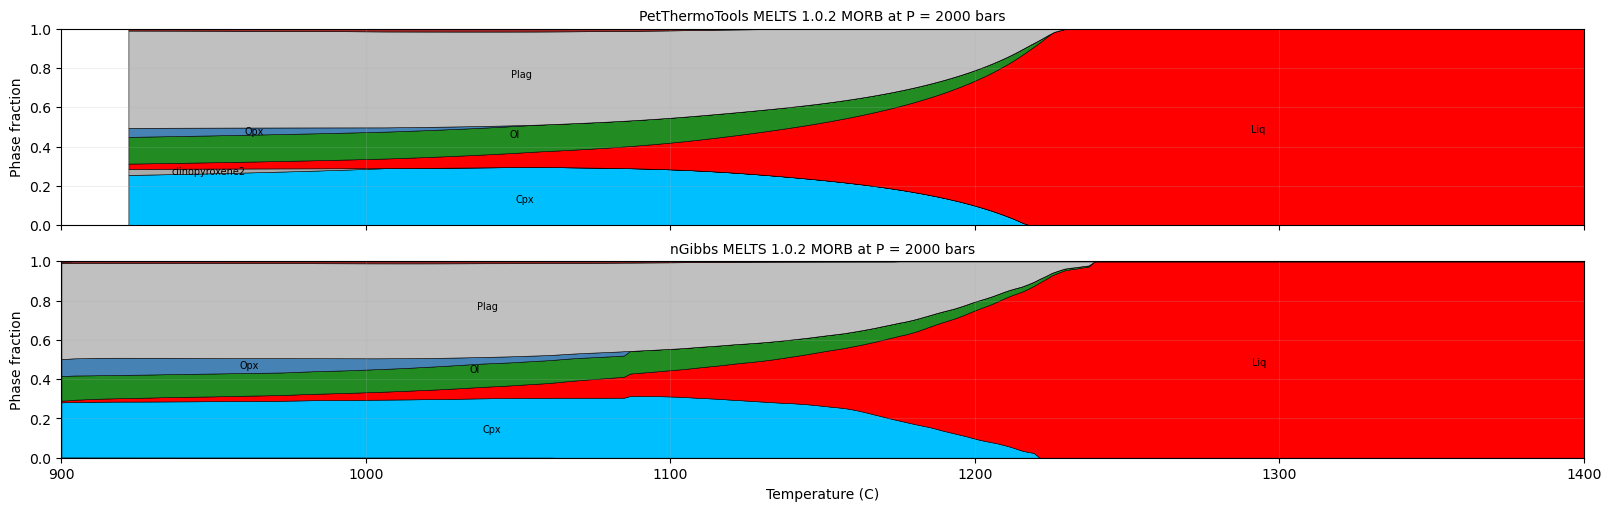

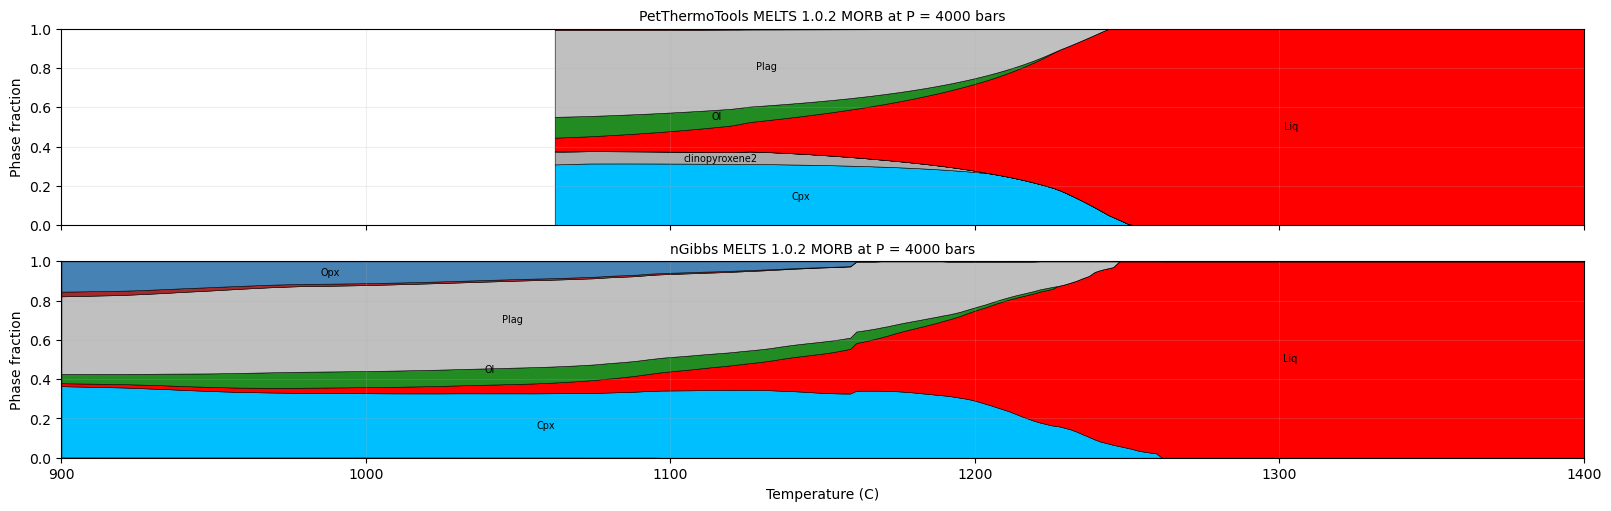

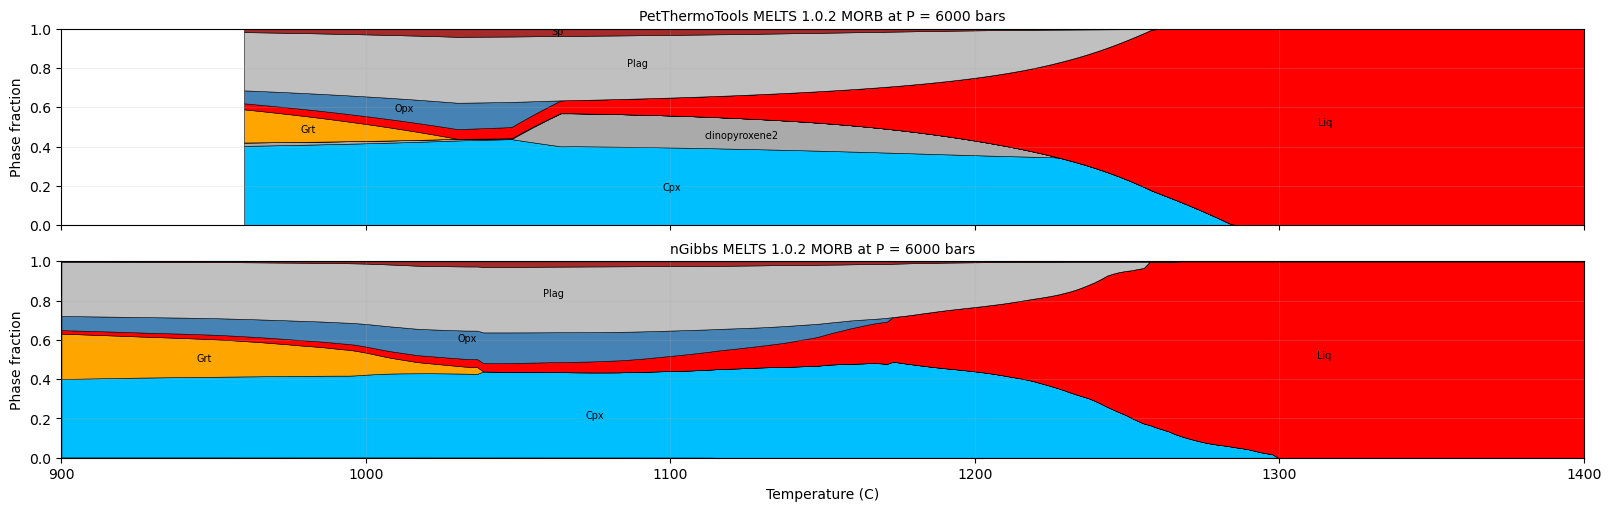

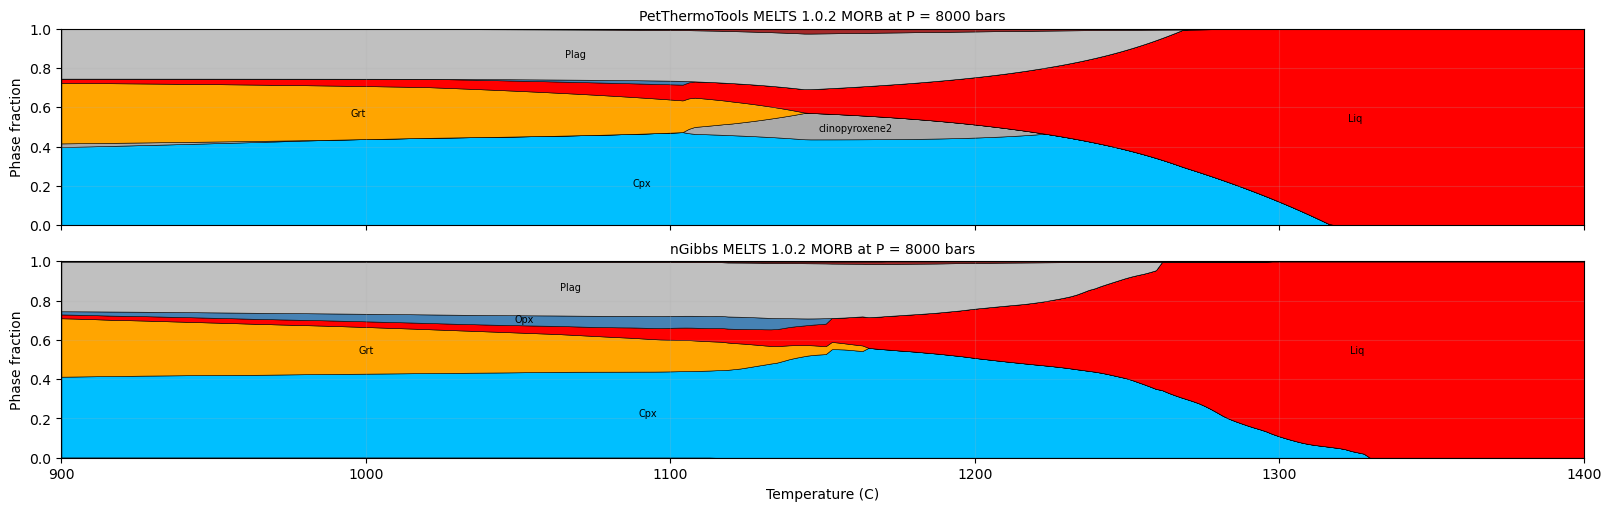

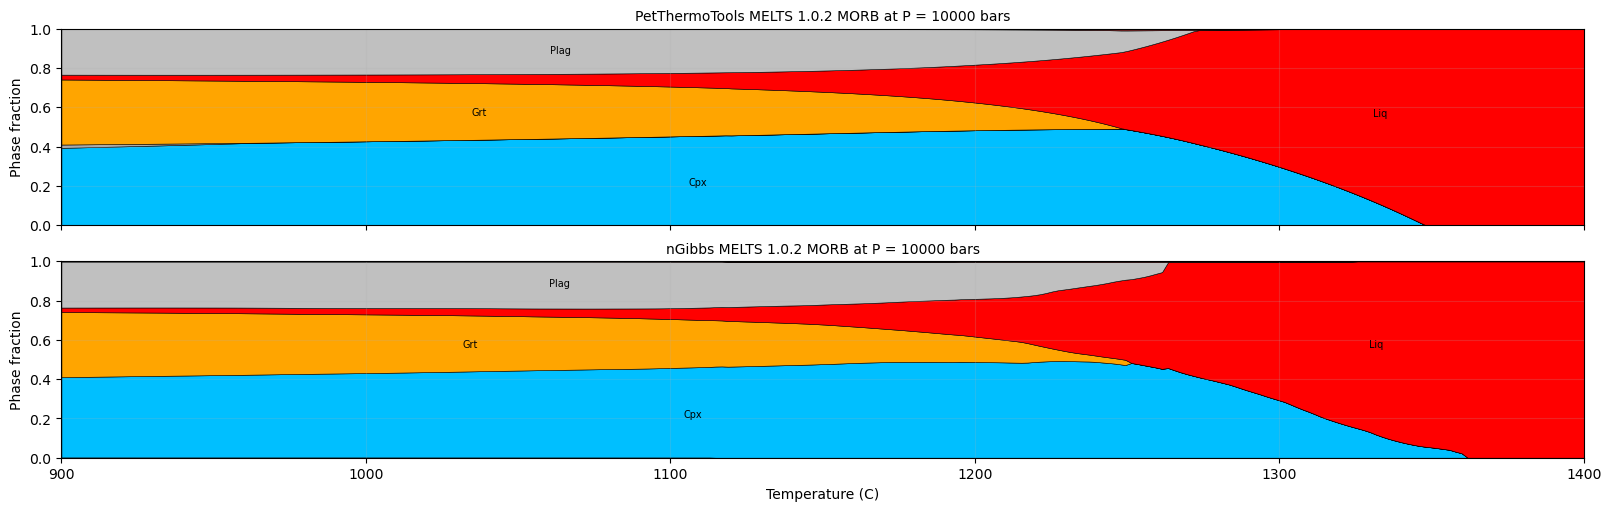

In [3]:
# Phase Abundances during cooling/melting at constant pressure

scripts_root = repo_root / "scripts"

if str(scripts_root) not in sys.path:
    sys.path.insert(0, str(scripts_root))
    

from melts_phase_animation import _draw_stack, melts_colors


for i in range(len(P_bar)):
    P = P_bar[i]
    try:
        ptt_phase_frame = ptt_polybaric[f'Run {i}']

        
    except:
        print(f"Warning: No PTT data found for P = {P} bars. Skipping.")
        continue
    nGibbs_phase_frame = nGibbs_polybaric[f'Run {i}']


    # Now get the same ordering as ptt... I see that it is alphabetical: I wrote this for an older version of ptt that had different ordering
    ptt_cols = ptt_phase_frame['mass_g'].columns.to_list()
    nGibbs_cols = nGibbs_phase_frame['mass_g'].columns.to_list()
    phase_order = []
    PhaseNo = 0
    for pCol in ptt_cols:
        if pCol in nGibbs_cols:
            phase_order.append(pCol)
            PhaseNo += 1
        else:
            phase_order.append(None) # Placeholder for missing phase in nGibbs output

    for i, gCol in enumerate(phase_order):
            if gCol is None:
                phase_order.append(nGibbs_cols[i]) # Add any extra phases in nGibbs output that weren't in ptt output, but put them at the end of the order.
    
    phase_order = np.array([p for p in phase_order if p is not None]) # Remove any None placeholders from the order



    fig, (ax_a, ax_b) = plt.subplots(2,1, figsize=(16, 5),
                                        sharex=True, constrained_layout=True)

    _draw_stack(ax_a, ptt_phase_frame['Conditions']['T_C'], ptt_phase_frame['mass_g']/100,
                    ptt_cols, colors=melts_colors(), title=f'PetThermoTools MELTS 1.0.2 MORB at P = {int(P)} bars',
                    x_name= '')
    _draw_stack(ax_b, nGibbs_phase_frame['Conditions']['T_C'], nGibbs_phase_frame['mass_g'][phase_order]/100,
                    phase_order, colors=melts_colors(), title=f'nGibbs MELTS 1.0.2 MORB at P = {int(P)} bars',
                    x_name= 'Temperature (C)')
    plt.show()

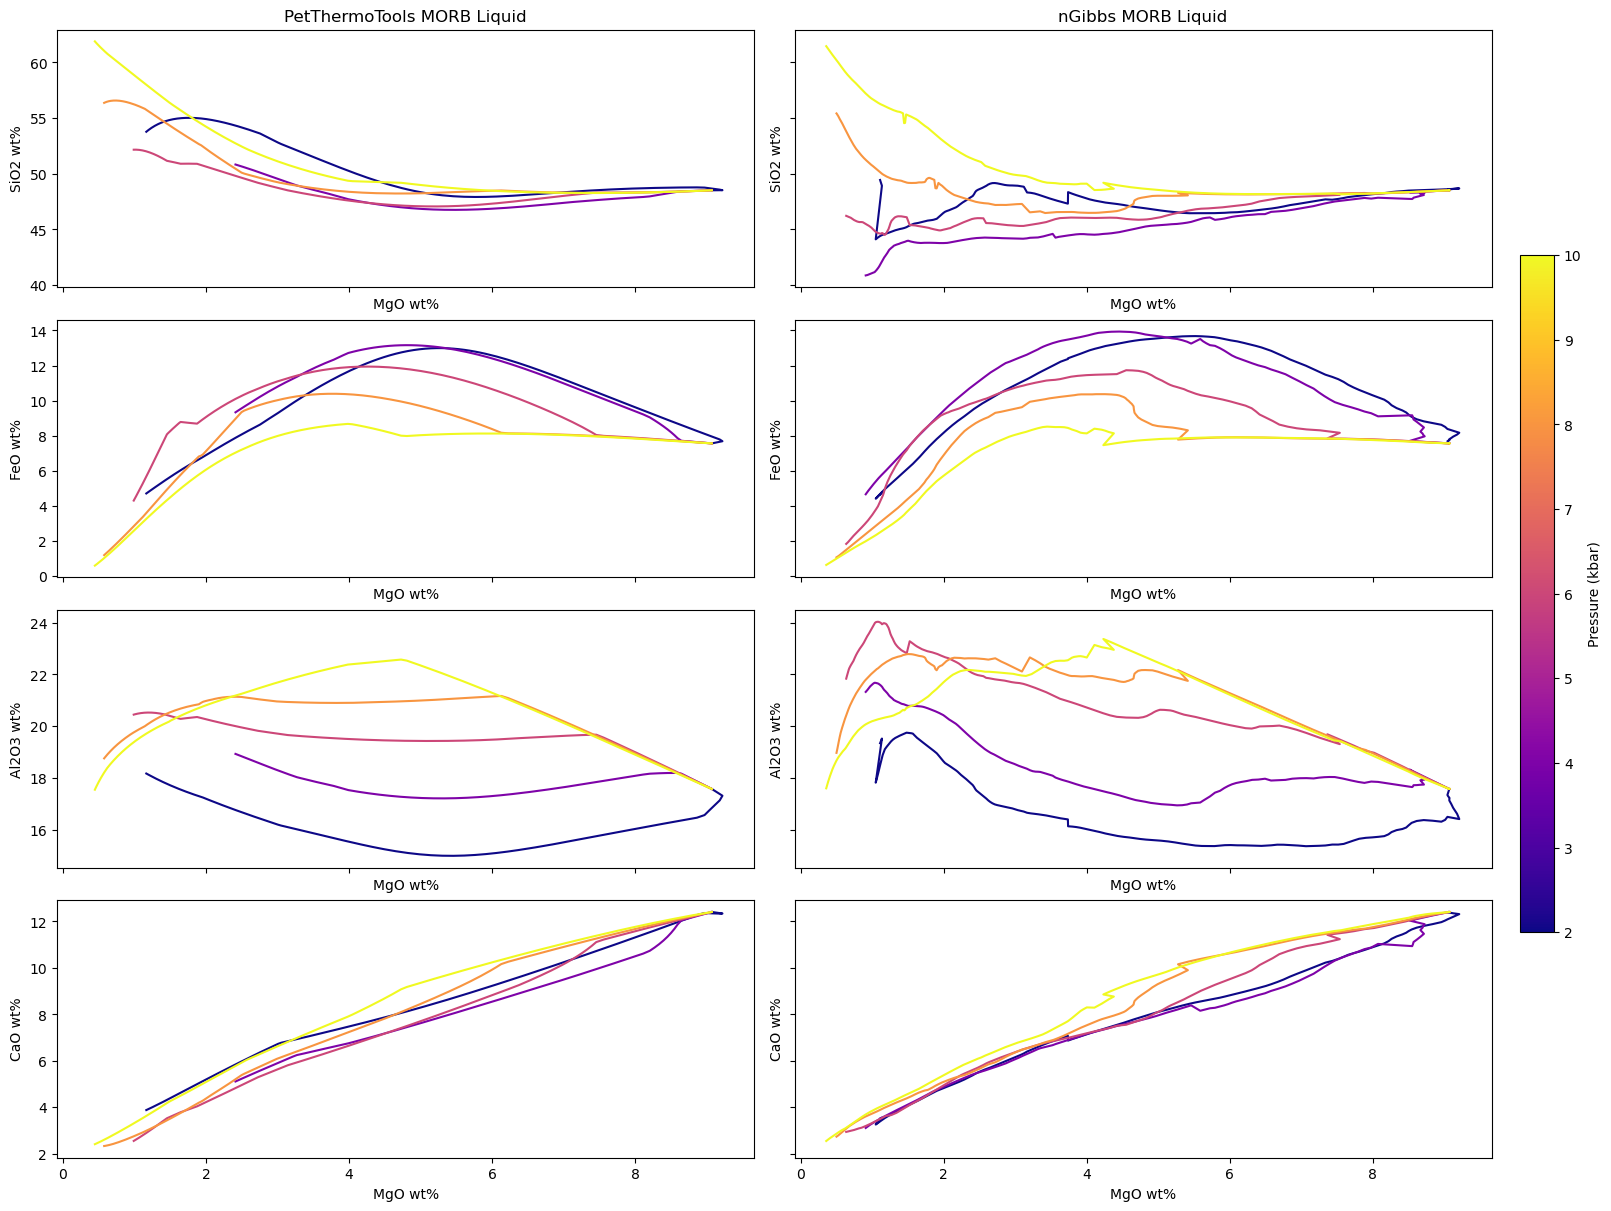

In [5]:
#Harkers!
oxides_to_plot = (
    ('liquid1', 'MgO', 'SiO2'),
    ('liquid1', 'MgO', 'FeO'),
    ('liquid1', 'MgO', 'Al2O3'),
    ('liquid1', 'MgO', 'CaO')
)

cmap = plt.cm.plasma
pressure_colors = [cmap(i / (len(P_bar) - 1)) for i in range(len(P_bar))]

fig, axes = plt.subplots(len(oxides_to_plot), 2, figsize=(16, 12), constrained_layout=True, sharex=True, sharey='row')

for i in range(len(P_bar)):
    P = P_bar[i]
    color = pressure_colors[i]
    try:
        ptt_phase_frame = ptt_polybaric[f'Run {i}']
    except:
        print(f"Warning: No PTT data found for P = {P} bars. Skipping.")
        continue
    nGibbs_phase_frame = nGibbs_polybaric[f'Run {i}']

    for j, (phase, x_oxide, y_oxide) in enumerate(oxides_to_plot):
        ax1, ax2 = axes[j]
        ax1.plot(ptt_phase_frame[phase][x_oxide + ptt_to_short[phase]],
                    ptt_phase_frame[phase][y_oxide + ptt_to_short[phase]],
                    color=color)
        ax2.plot(nGibbs_phase_frame[phase][x_oxide + ptt_to_short[phase]],
                    nGibbs_phase_frame[phase][y_oxide + ptt_to_short[phase]],
                    color=color)

for j, (phase, x_oxide, y_oxide) in enumerate(oxides_to_plot):
    ax1, ax2 = axes[j]
    ax1.set_xlabel(f'{x_oxide} wt%')
    ax1.set_ylabel(f'{y_oxide} wt%')
    ax2.set_xlabel(f'{x_oxide} wt%')
    ax2.set_ylabel(f'{y_oxide} wt%')

axes[0][0].set_title('PetThermoTools MORB Liquid')
axes[0][1].set_title('nGibbs MORB Liquid')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=P_bar.min() / 1000, vmax=P_bar.max() / 1000))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, location='right', shrink=0.6, pad=0.02)
cbar.set_label('Pressure (kbar)')

plt.show()

It's interesting that the emulator is so scribbly and jumpy... There is probably a way to smooth this out. One idea is to cook up a scheme to teach it about metastability, or somehow teach it dimensional information like phase diagrams. I think it can be done...

Currently the training is probably confusing to it because of how abruptly the mass balance changes when a phase is flipped on or off

Attempt 0
Attempt 1
Attempt 2
Attempt 3
Attempt 4
PetThermoTools phase diagram calculation completed in 45.61 seconds.


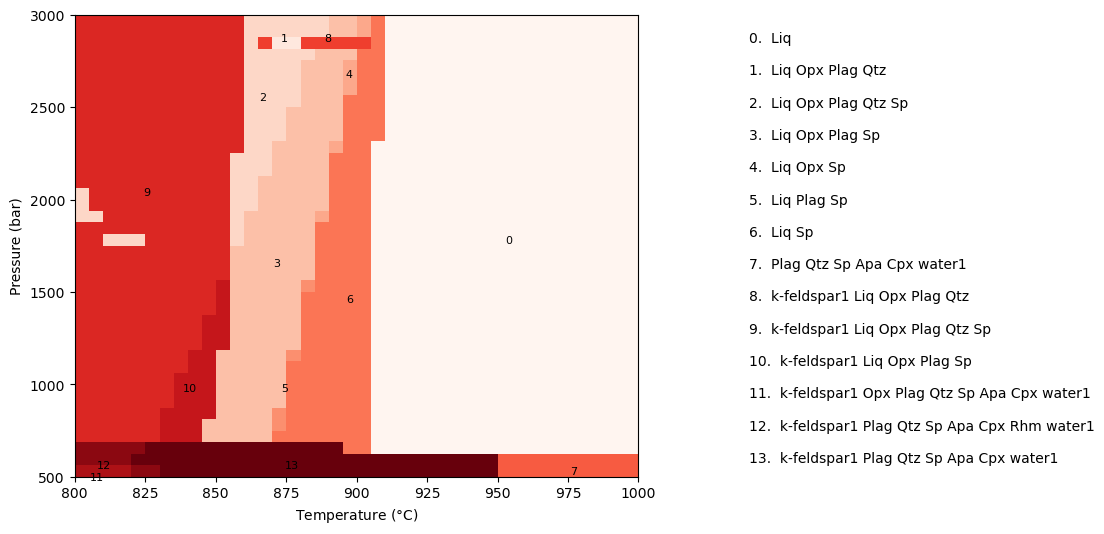

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: xlabel='Temperature ($\\degree$C)', ylabel='Pressure (bar)'>,
        <Axes: >], dtype=object))

In [19]:

#PetThermoTools phase diagrams!

begin_Phase_Diagram = time()
ptt_Phase_Diagram = ptt.phaseDiagram_calc(Model = "MELTSv1.0.2", bulk = compositions['Bishop_Tuff'], 
                            P_bar = np.linspace(500.0,3000.0, 40),
                            T_C = np.linspace(800.0, 1000.0, 40),
                            i_max = 15) # Longer timeout for phase diagram calculations, which are more computationally intensive.
print(f"PetThermoTools phase diagram calculation completed in {time() - begin_Phase_Diagram:.2f} seconds.")

ptt.plot_phaseDiagram(Model = "MELTSv1.0.2", Combined=ptt_Phase_Diagram)


Okay! That should be enough to get you started. I think I'll need to emulate the contents of the ptt outputs a little more faithfully for the phase diagram to work... 